<a href="https://colab.research.google.com/github/vinaykumarbm2005-git/Data-visualization/blob/main/internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/abhiva_dataset.csv')
print(df)

       StudentID        StudentName     Grade  \
0      STU000001                NaN   Grade 8   
1      STU000002        Sean Harris   Grade 8   
2      STU000003        Yvonne Cole  Grade 10   
3      STU000004       Jesse Jensen   Grade 8   
4      STU000005    Earline Calisto   Class 7   
...          ...                ...       ...   
19995  STU019996                NaN   Class 8   
19996  STU019997   Cynthia Caldwell  Grade 10   
19997  STU019998      Richard Bryan   Class 8   
19998  STU019999        Eleanor Lor   Class 8   
19999  STU020000  Melissa Mcclendon   Grade 9   

                                 Email AssessmentID           Subject  \
0            james.clyde164@school.edu     ASM00002          Accounts   
1             sean.harris79@school.edu     ASM00003         Economics   
2                                  NaN     ASM00004  Computer Science   
3           jesse.jensen727@school.edu     ASM00005           History   
4        earline.calisto408@school.edu     ASM

In [2]:
#df.head()
#df.tail()
#df.shape
#print(df.columns)
print(df.dtypes)
#print(df.isnull().sum())
#print(df.describe)
#print(df.duplicated().sum())

StudentID            object
StudentName          object
Grade                object
Email                object
AssessmentID         object
Subject              object
TotalMarks            int64
QuestionID           object
CorrectAnswer        object
ResultID             object
MarksObtained         int64
Percentage          float64
AttemptDate          object
TeacherName          object
AttendanceStatus     object
dtype: object


# Data Cleaning

In [3]:
clean_df = df.copy()
print(clean_df)


       StudentID        StudentName     Grade  \
0      STU000001                NaN   Grade 8   
1      STU000002        Sean Harris   Grade 8   
2      STU000003        Yvonne Cole  Grade 10   
3      STU000004       Jesse Jensen   Grade 8   
4      STU000005    Earline Calisto   Class 7   
...          ...                ...       ...   
19995  STU019996                NaN   Class 8   
19996  STU019997   Cynthia Caldwell  Grade 10   
19997  STU019998      Richard Bryan   Class 8   
19998  STU019999        Eleanor Lor   Class 8   
19999  STU020000  Melissa Mcclendon   Grade 9   

                                 Email AssessmentID           Subject  \
0            james.clyde164@school.edu     ASM00002          Accounts   
1             sean.harris79@school.edu     ASM00003         Economics   
2                                  NaN     ASM00004  Computer Science   
3           jesse.jensen727@school.edu     ASM00005           History   
4        earline.calisto408@school.edu     ASM

In [4]:
print(clean_df.isnull().sum())

StudentID              0
StudentName         2072
Grade                  0
Email               1917
AssessmentID           0
Subject                0
TotalMarks             0
QuestionID             0
CorrectAnswer          0
ResultID               0
MarksObtained          0
Percentage             0
AttemptDate            0
TeacherName            0
AttendanceStatus       0
dtype: int64


Remove the complete row wherever StudentName is empty/missing by dropna.

In [5]:
clean_df = clean_df.dropna(subset=["StudentName"])

Check weather those rows are removed or not

In [6]:
clean_df.shape

(17928, 15)

Nameing email as abc@gmail.com by fillna.

In [7]:
clean_df["Email"] = clean_df["Email"].fillna("abc@gmail.com")

day/month/year format

In [8]:
clean_df["AttemptDate"] = pd.to_datetime(
    clean_df["AttemptDate"],
    format="%Y-%m-%d"
)

checking cleaning part

In [9]:
clean_df.shape

(17928, 15)

In [10]:
clean_df.isnull().sum()

,0
StudentID,0
StudentName,0
Grade,0
Email,0
AssessmentID,0
Subject,0
TotalMarks,0
QuestionID,0
CorrectAnswer,0
ResultID,0


In [11]:
clean_df.isnull().sum()

,0
StudentID,0
StudentName,0
Grade,0
Email,0
AssessmentID,0
Subject,0
TotalMarks,0
QuestionID,0
CorrectAnswer,0
ResultID,0


#Visualization

1.Calculate average percentage for each subject

In [12]:
subject_performance = clean_df.groupby("Subject")["Percentage"].mean()
subject_performance

,Percentage
Subject,
Accounts,50.022151
Biology,49.260111
Chemistry,49.678839
Computer Science,49.449849
Economics,49.930011
English,49.948152
Geography,49.300041
History,50.383787
Mathematics,49.530756


1.Average Student Performance by Subject

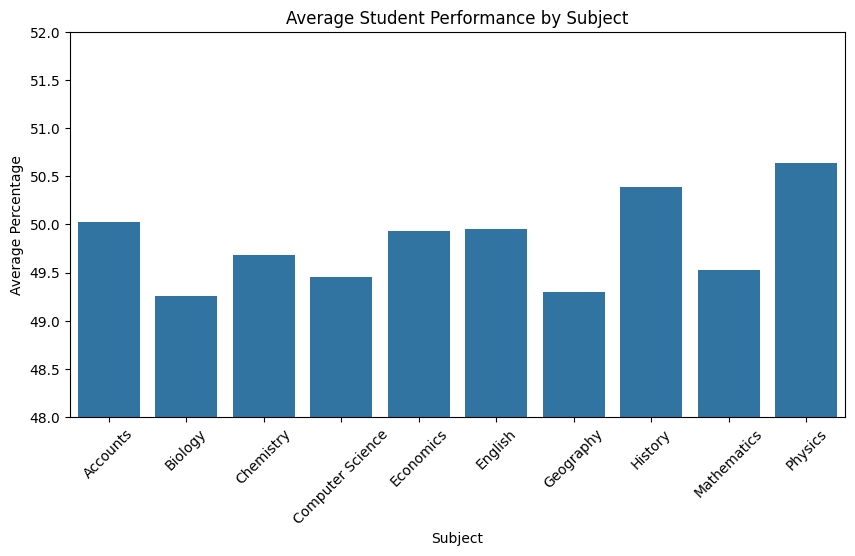

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

subject_performance = clean_df.groupby("Subject")["Percentage"].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=subject_performance.index, y=subject_performance.values)
plt.title("Average Student Performance by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Percentage")
plt.ylim(48, 52)
plt.xticks(rotation=45)
plt.show()

2.The distribution of students across different attendance statuses

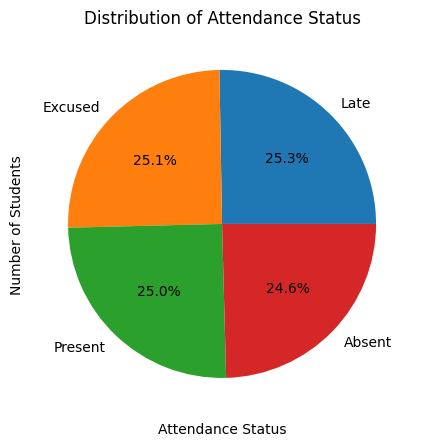

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

attendance_count = clean_df["AttendanceStatus"].value_counts()
plt.figure(figsize=(10,5))
plt.pie(attendance_count, labels=attendance_count.index, autopct="%1.1f%%")
plt.title("Distribution of Attendance Status")
plt.xlabel("Attendance Status")
plt.ylabel("Number of Students")
plt.show()

3.How does the average student percentage change over time?

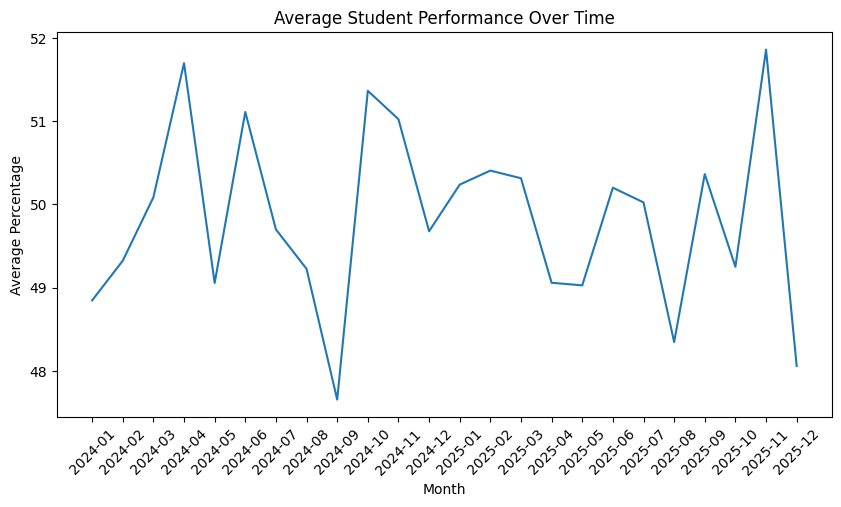

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_performance = clean_df.groupby(
    clean_df["AttemptDate"].dt.to_period("M")
)["Percentage"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_performance.index.astype(str),y=monthly_performance.values)
plt.title("Average Student Performance Over Time")
plt.xlabel("Month")
plt.ylabel("Average Percentage")
plt.xticks(rotation=45)
plt.show()

4.Total Marks vs Marks Obtained

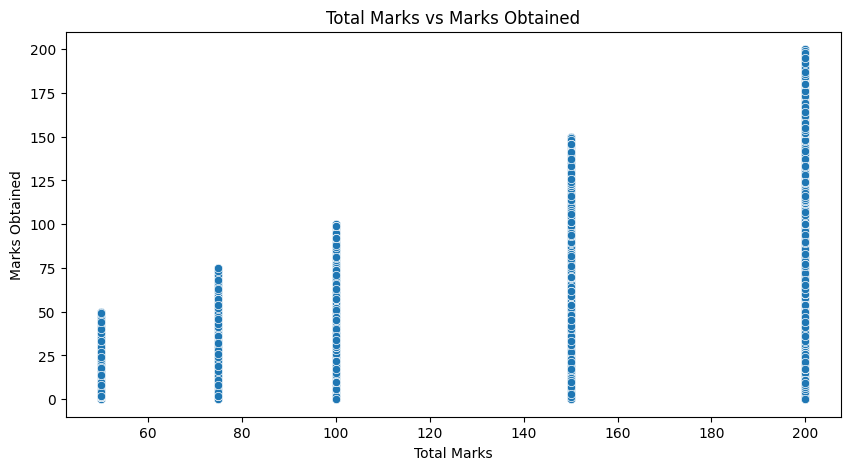

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.scatterplot(x=clean_df["TotalMarks"], y=clean_df["MarksObtained"])
plt.title("Total Marks vs Marks Obtained")
plt.xlabel("Total Marks")
plt.ylabel("Marks Obtained")
plt.show()

5.The students' percentages distributed

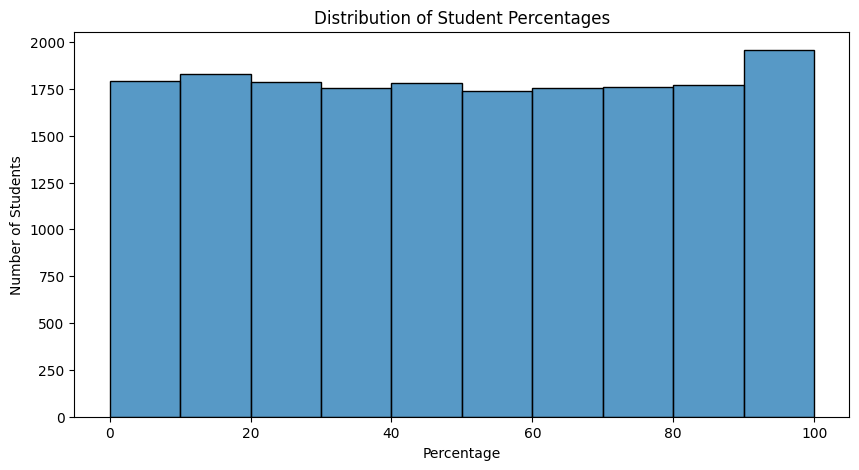

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(clean_df["Percentage"], bins=10)
plt.title("Distribution of Student Percentages")
plt.xlabel("Percentage")
plt.ylabel("Number of Students")
plt.show()

6.student percentage vary across different grades

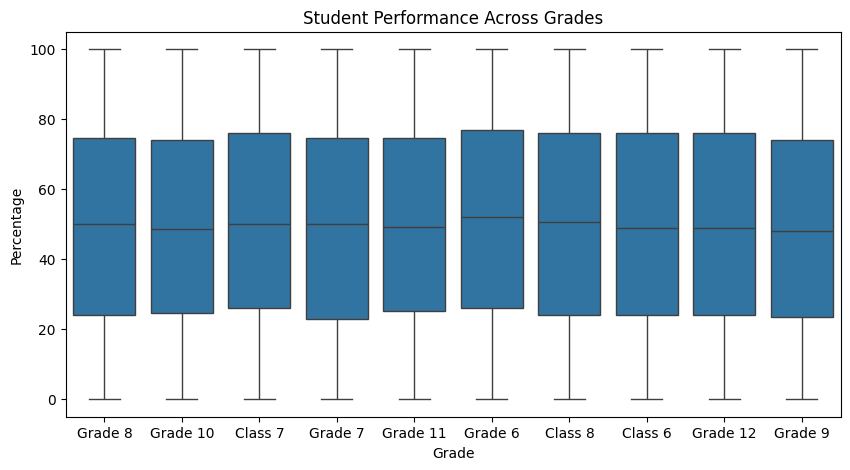

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(x=clean_df["Grade"], y=clean_df["Percentage"])
plt.title("Student Performance Across Grades")
plt.xlabel("Grade")
plt.ylabel("Percentage")
plt.show()

7.Student percentage vary based on attendance status

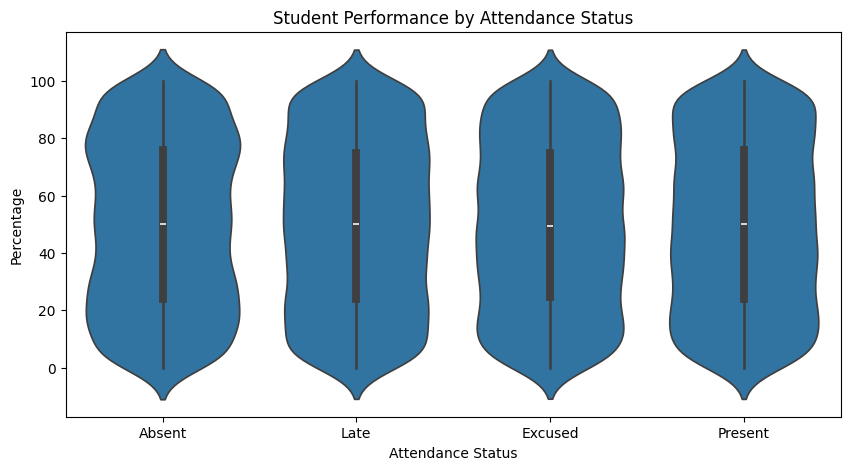

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.violinplot(x=clean_df["AttendanceStatus"], y=clean_df["Percentage"])
plt.title("Student Performance by Attendance Status")
plt.xlabel("Attendance Status")
plt.ylabel("Percentage")
plt.show()

8.Average student performance vary across subjects and attendance statuses

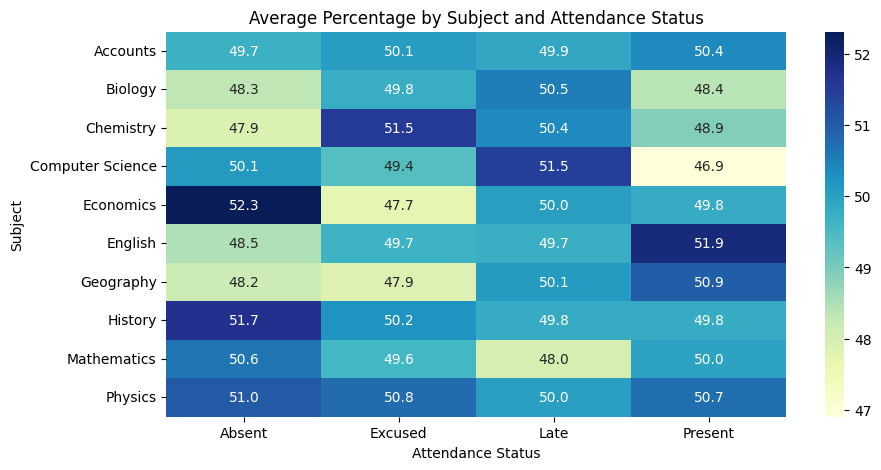

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

subject_attendance = clean_df.pivot_table(
    values="Percentage",
    index="Subject",
    columns="AttendanceStatus",
    aggfunc="mean"
)

plt.figure(figsize=(10,5))
sns.heatmap(subject_attendance, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average Percentage by Subject and Attendance Status")
plt.xlabel("Attendance Status")
plt.ylabel("Subject")
plt.show()

9.The number of assessment attempts change over time

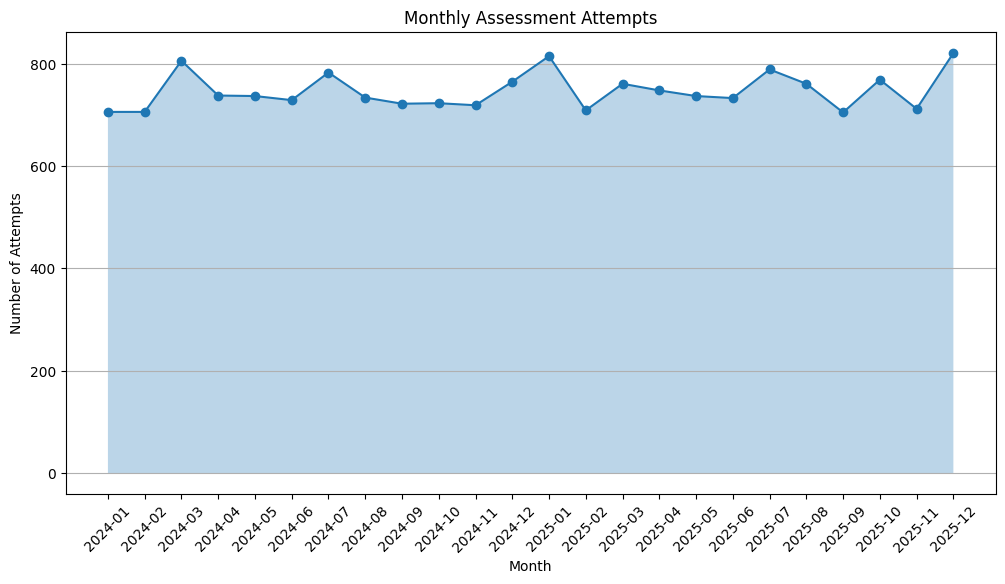

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly_attempts = clean_df.groupby(
    clean_df["AttemptDate"].dt.to_period("M")
).size()

plt.figure(figsize=(12,6))

plt.fill_between(
    monthly_attempts.index.astype(str),
    monthly_attempts.values,
    alpha=0.3
)

plt.plot(
    monthly_attempts.index.astype(str),
    monthly_attempts.values,
    marker="o"
)
plt.title("Monthly Assessment Attempts")
plt.xlabel("Month")
plt.ylabel("Number of Attempts")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

10.The average percentage differ across different teachers

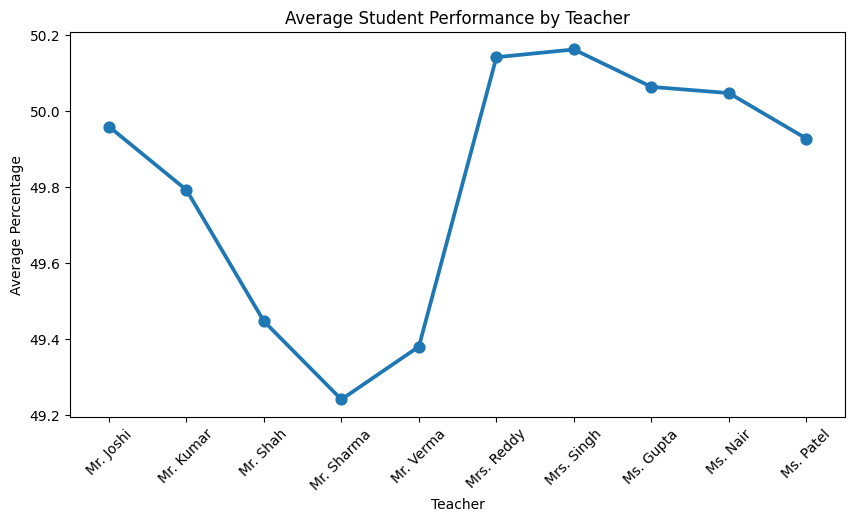

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

teacher_performance = clean_df.groupby("TeacherName")["Percentage"].mean()

plt.figure(figsize=(10,5))

sns.pointplot(x=teacher_performance.index, y=teacher_performance.values)

plt.title("Average Student Performance by Teacher")
plt.xlabel("Teacher")
plt.ylabel("Average Percentage")
plt.xticks(rotation=45)
plt.show()

ALL  IN ONE HORIZONTAL

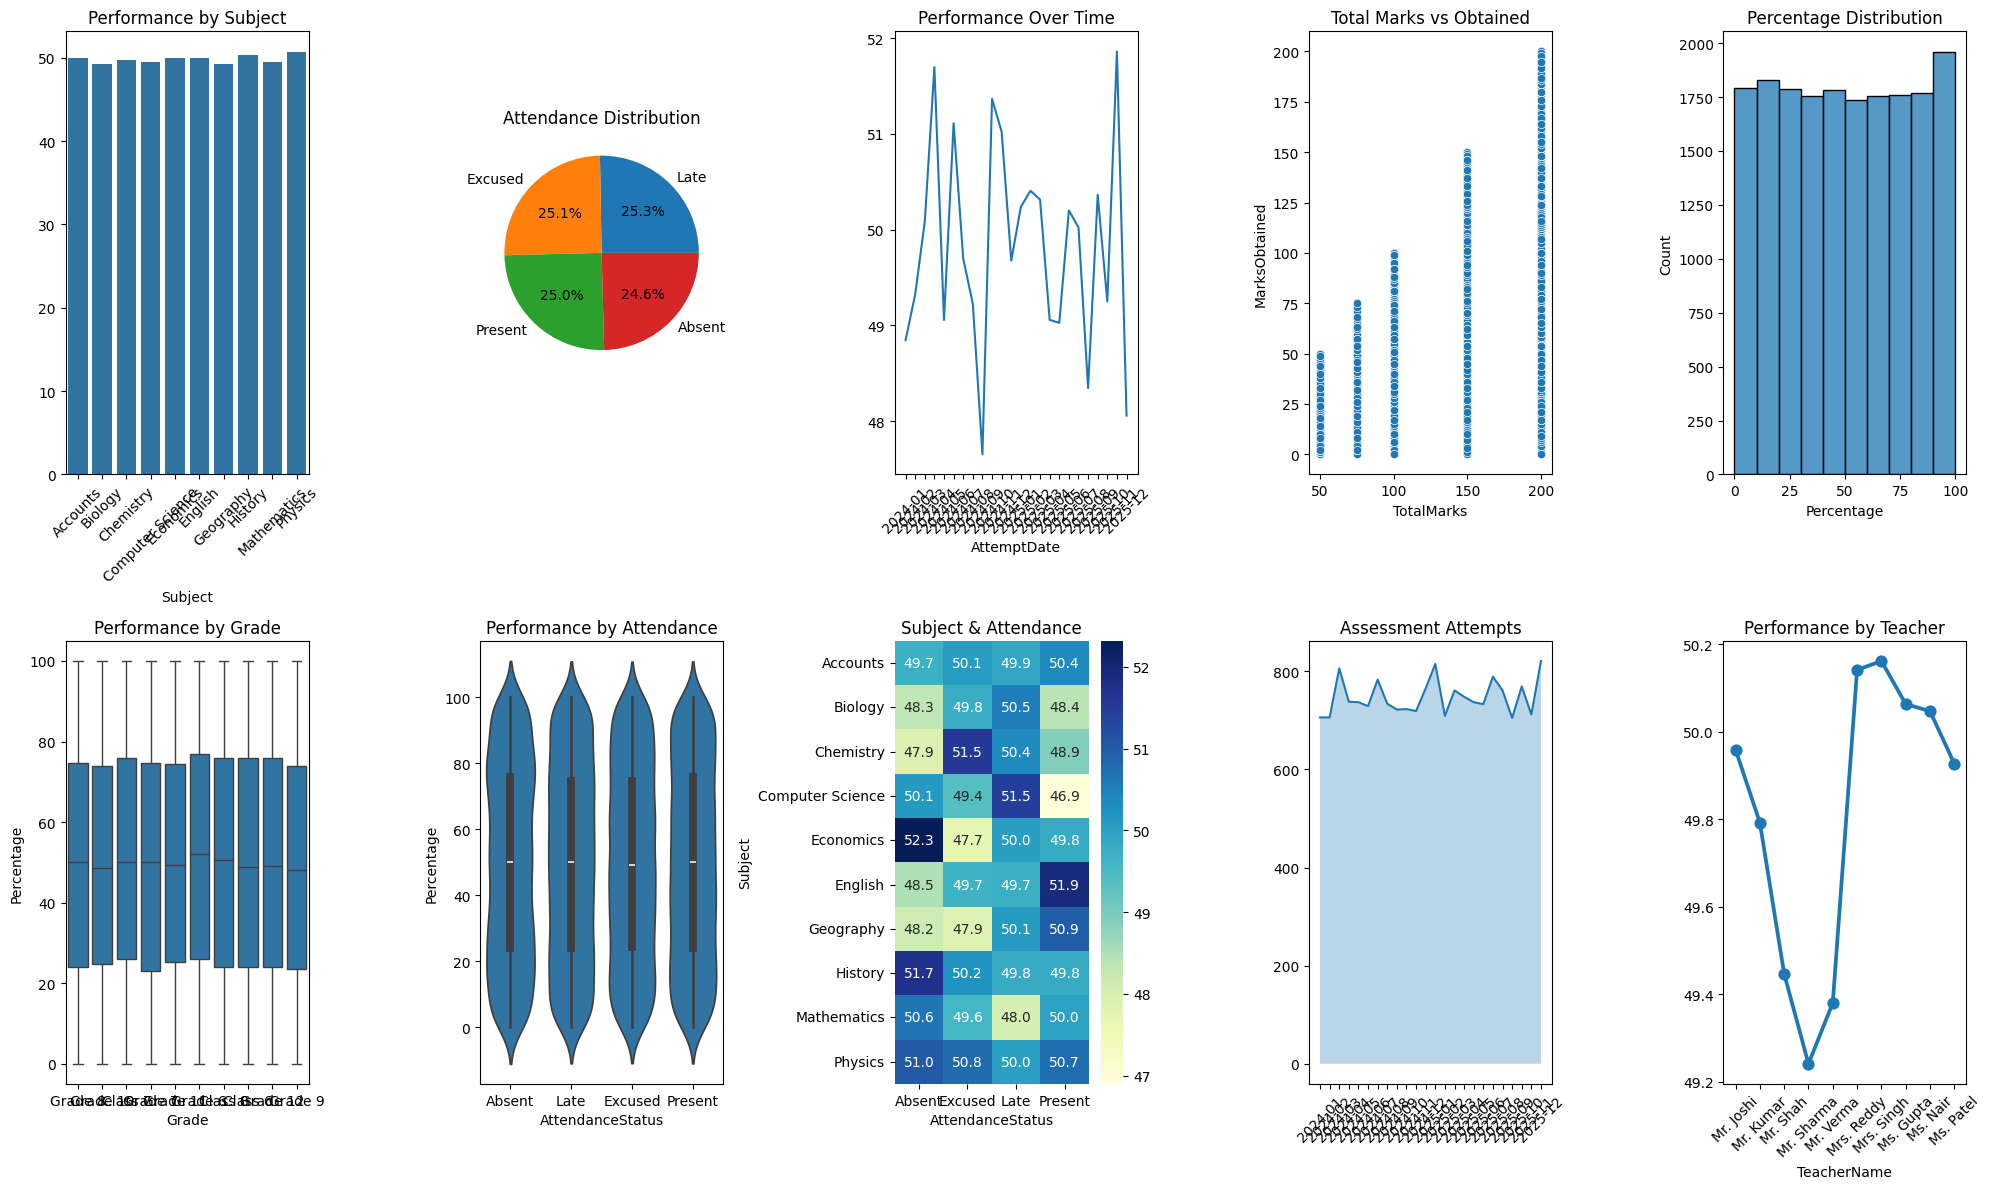

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 12))

# Chart 1 - Subject Performance
plt.subplot(2, 5, 1)
subject_performance = clean_df.groupby("Subject")["Percentage"].mean()
sns.barplot(x=subject_performance.index, y=subject_performance.values)
plt.title("Performance by Subject")
plt.xticks(rotation=45)

# Chart 2 - Attendance Distribution
plt.subplot(2, 5, 2)
attendance_count = clean_df["AttendanceStatus"].value_counts()
plt.pie(attendance_count, labels=attendance_count.index, autopct="%1.1f%%")
plt.title("Attendance Distribution")

# Chart 3 - Performance Over Time
plt.subplot(2, 5, 3)
monthly_performance = clean_df.groupby(
    clean_df["AttemptDate"].dt.to_period("M")
)["Percentage"].mean()
sns.lineplot(
    x=monthly_performance.index.astype(str),
    y=monthly_performance.values
)
plt.title("Performance Over Time")
plt.xticks(rotation=45)

# Chart 4 - Total Marks vs Marks Obtained
plt.subplot(2, 5, 4)
sns.scatterplot(
    x=clean_df["TotalMarks"],
    y=clean_df["MarksObtained"]
)
plt.title("Total Marks vs Obtained")

# Chart 5 - Percentage Distribution
plt.subplot(2, 5, 5)
sns.histplot(clean_df["Percentage"], bins=10)
plt.title("Percentage Distribution")

# Chart 6 - Performance Across Grades
plt.subplot(2, 5, 6)
sns.boxplot(
    x=clean_df["Grade"],
    y=clean_df["Percentage"]
)
plt.title("Performance by Grade")

# Chart 7 - Performance by Attendance
plt.subplot(2, 5, 7)
sns.violinplot(
    x=clean_df["AttendanceStatus"],
    y=clean_df["Percentage"]
)
plt.title("Performance by Attendance")

# Chart 8 - Subject and Attendance
plt.subplot(2, 5, 8)
subject_attendance = clean_df.pivot_table(
    values="Percentage",
    index="Subject",
    columns="AttendanceStatus",
    aggfunc="mean"
)
sns.heatmap(
    subject_attendance,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Subject & Attendance")

# Chart 9 - Assessment Attempts
plt.subplot(2, 5, 9)
monthly_attempts = clean_df.groupby(
    clean_df["AttemptDate"].dt.to_period("M")
).size()

plt.fill_between(
    monthly_attempts.index.astype(str),
    monthly_attempts.values,
    alpha=0.3
)

plt.plot(
    monthly_attempts.index.astype(str),
    monthly_attempts.values
)

plt.title("Assessment Attempts")
plt.xticks(rotation=45)

# Chart 10 - Teacher Performance
plt.subplot(2, 5, 10)
teacher_performance = clean_df.groupby(
    "TeacherName"
)["Percentage"].mean()

sns.pointplot(
    x=teacher_performance.index,
    y=teacher_performance.values
)

plt.title("Performance by Teacher")
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

ALL IN ONE VERTICAL

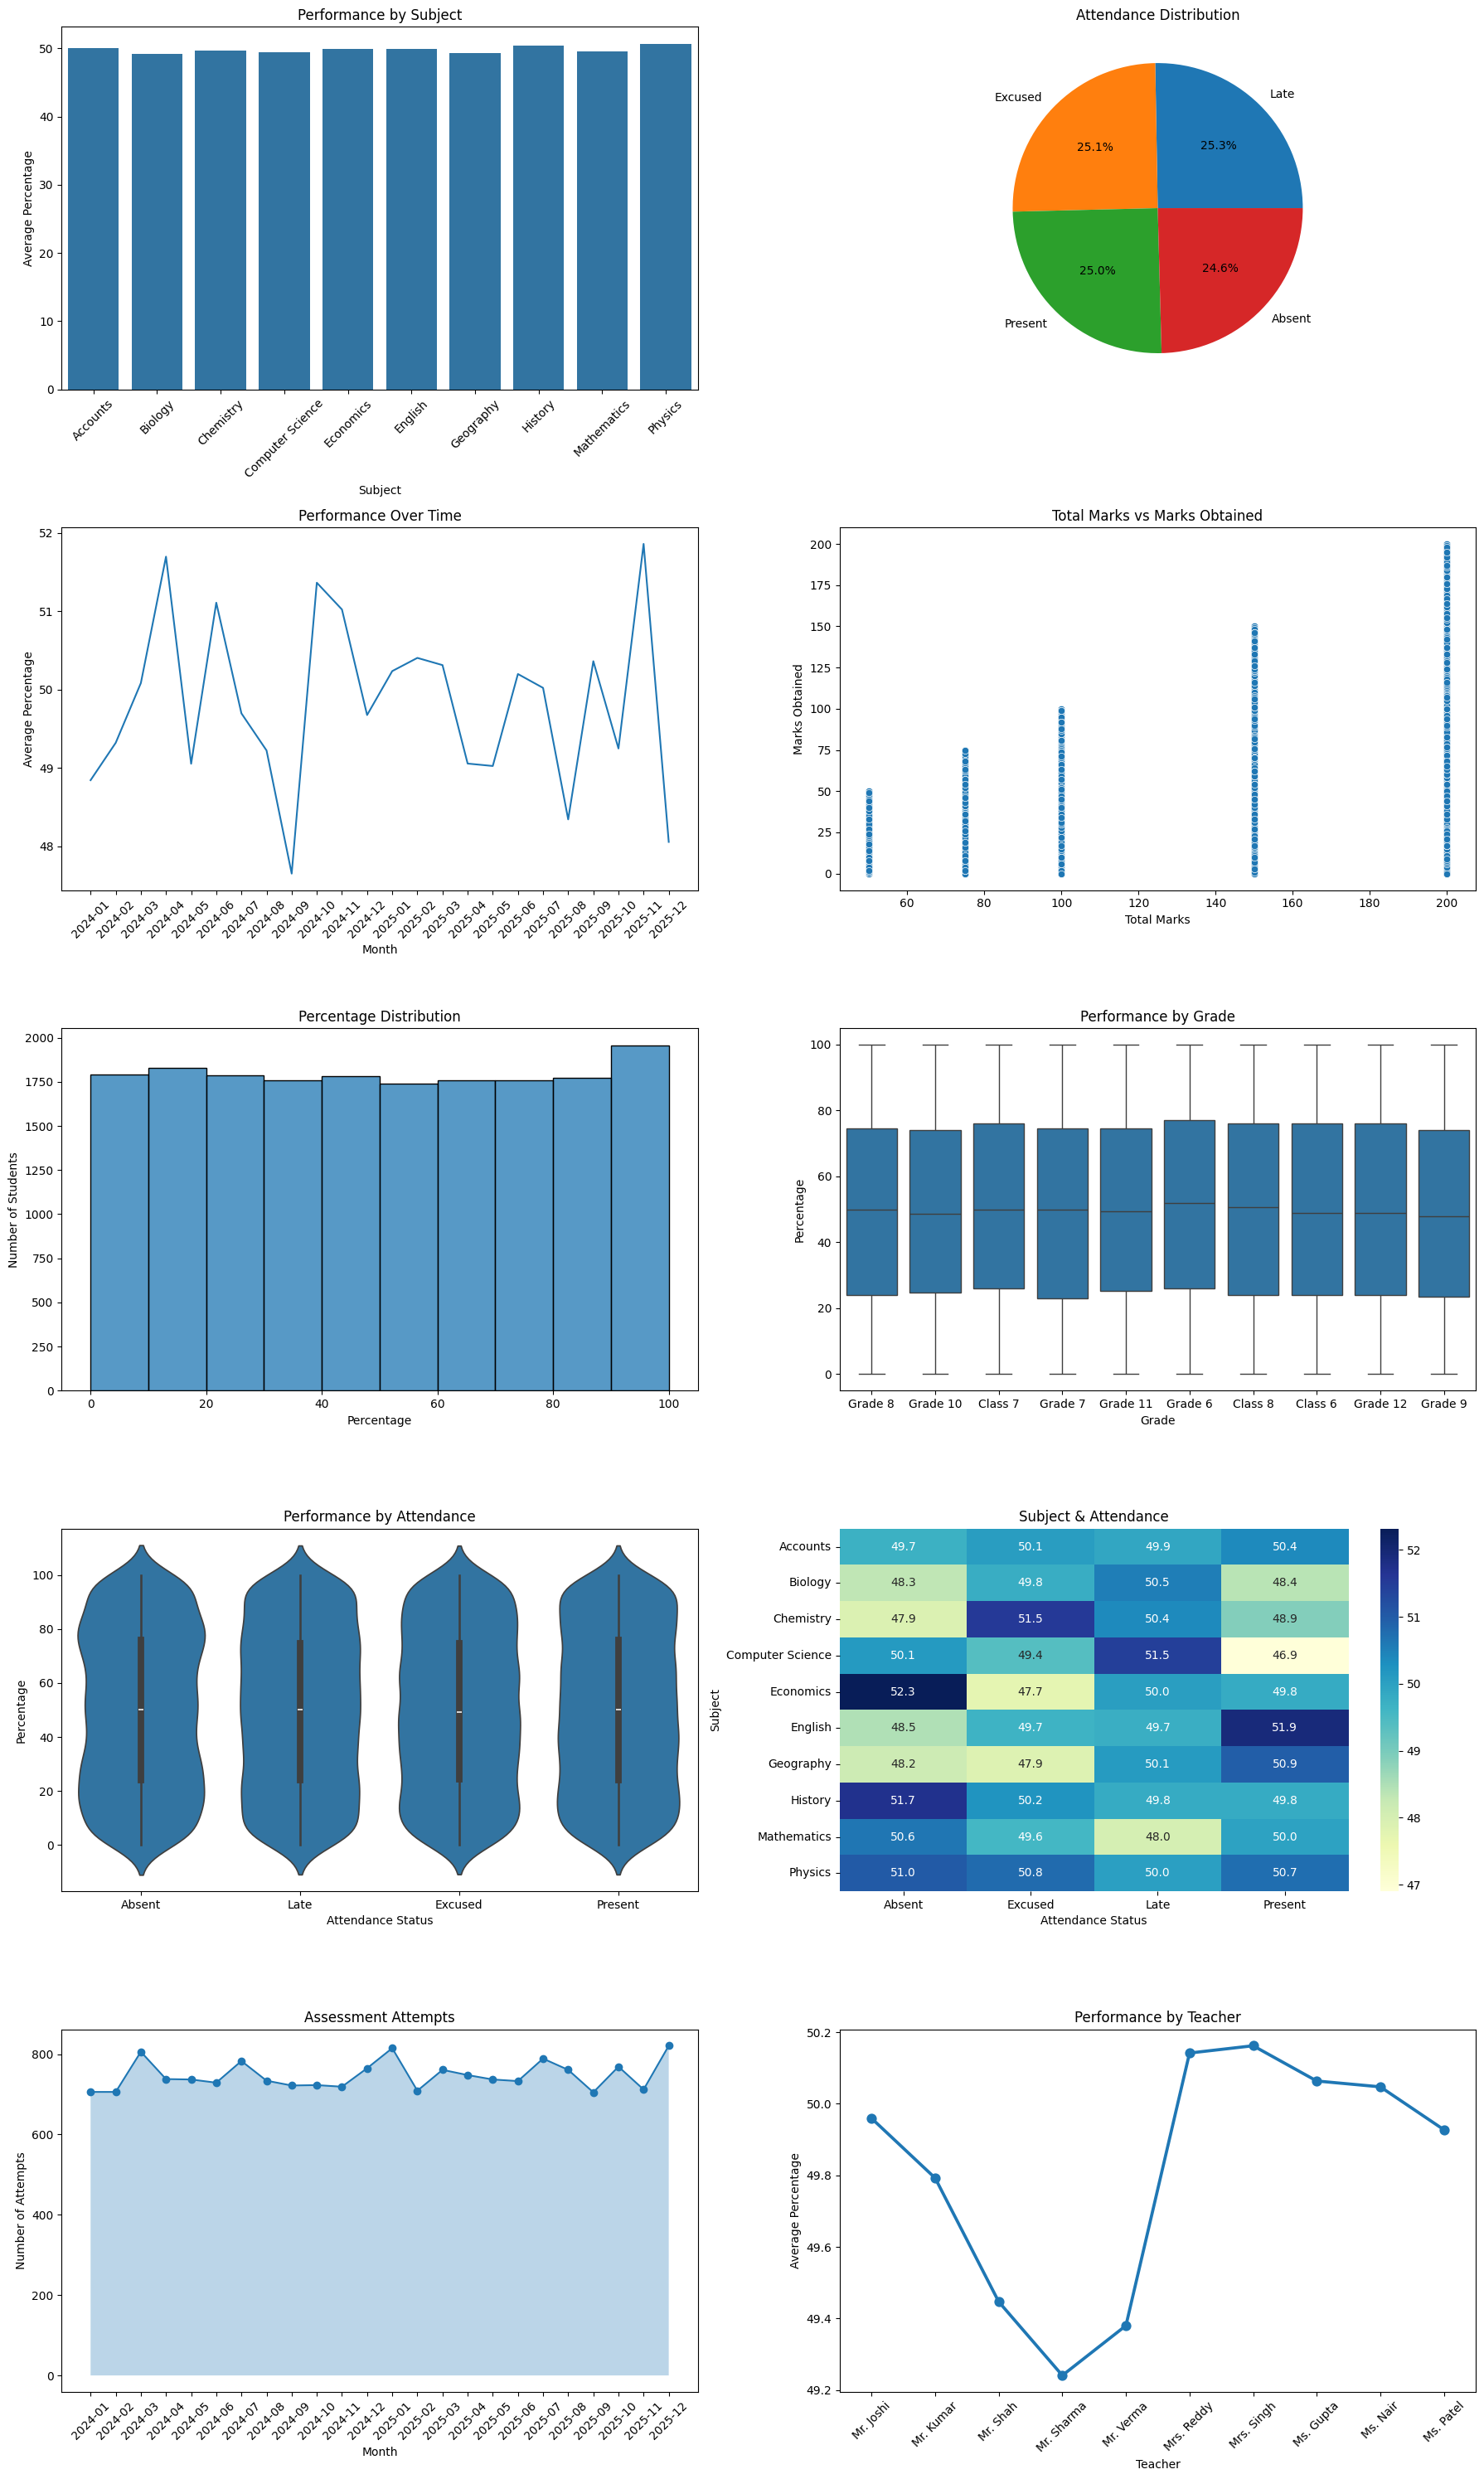

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 30))

# Chart 1 - Subject Performance
plt.subplot(5, 2, 1)

subject_performance = clean_df.groupby("Subject")["Percentage"].mean()

sns.barplot(x=subject_performance.index, y=subject_performance.values)

plt.title("Performance by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Percentage")
plt.xticks(rotation=45)


# Chart 2 - Attendance Distribution
plt.subplot(5, 2, 2)

attendance_count = clean_df["AttendanceStatus"].value_counts()

plt.pie(
    attendance_count,
    labels=attendance_count.index,
    autopct="%1.1f%%"
)

plt.title("Attendance Distribution")


# Chart 3 - Performance Over Time
plt.subplot(5, 2, 3)

monthly_performance = clean_df.groupby(
    clean_df["AttemptDate"].dt.to_period("M")
)["Percentage"].mean()

sns.lineplot(
    x=monthly_performance.index.astype(str),
    y=monthly_performance.values
)

plt.title("Performance Over Time")
plt.xlabel("Month")
plt.ylabel("Average Percentage")
plt.xticks(rotation=45)


# Chart 4 - Total Marks vs Marks Obtained
plt.subplot(5, 2, 4)

sns.scatterplot(
    x=clean_df["TotalMarks"],
    y=clean_df["MarksObtained"]
)

plt.title("Total Marks vs Marks Obtained")
plt.xlabel("Total Marks")
plt.ylabel("Marks Obtained")


# Chart 5 - Percentage Distribution
plt.subplot(5, 2, 5)

sns.histplot(
    clean_df["Percentage"],
    bins=10
)

plt.title("Percentage Distribution")
plt.xlabel("Percentage")
plt.ylabel("Number of Students")


# Chart 6 - Performance Across Grades
plt.subplot(5, 2, 6)

sns.boxplot(
    x=clean_df["Grade"],
    y=clean_df["Percentage"]
)

plt.title("Performance by Grade")
plt.xlabel("Grade")
plt.ylabel("Percentage")


# Chart 7 - Performance by Attendance
plt.subplot(5, 2, 7)

sns.violinplot(
    x=clean_df["AttendanceStatus"],
    y=clean_df["Percentage"]
)

plt.title("Performance by Attendance")
plt.xlabel("Attendance Status")
plt.ylabel("Percentage")


# Chart 8 - Subject & Attendance
plt.subplot(5, 2, 8)

subject_attendance = clean_df.pivot_table(
    values="Percentage",
    index="Subject",
    columns="AttendanceStatus",
    aggfunc="mean"
)

sns.heatmap(
    subject_attendance,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Subject & Attendance")
plt.xlabel("Attendance Status")
plt.ylabel("Subject")


# Chart 9 - Assessment Attempts
plt.subplot(5, 2, 9)

monthly_attempts = clean_df.groupby(
    clean_df["AttemptDate"].dt.to_period("M")
).size()

plt.fill_between(
    monthly_attempts.index.astype(str),
    monthly_attempts.values,
    alpha=0.3
)

plt.plot(
    monthly_attempts.index.astype(str),
    monthly_attempts.values,
    marker="o"
)

plt.title("Assessment Attempts")
plt.xlabel("Month")
plt.ylabel("Number of Attempts")
plt.xticks(rotation=45)


# Chart 10 - Teacher Performance
plt.subplot(5, 2, 10)

teacher_performance = clean_df.groupby(
    "TeacherName"
)["Percentage"].mean()

sns.pointplot(
    x=teacher_performance.index,
    y=teacher_performance.values
)

plt.title("Performance by Teacher")
plt.xlabel("Teacher")
plt.ylabel("Average Percentage")
plt.xticks(rotation=45)


plt.tight_layout()

plt.show()

cleaned file

In [26]:
clean_df.to_csv("cleaned_data.csv", index=False)